In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
# use retina mode
plt.rcParams['figure.dpi'] = 200

In [4]:
def format_figure(ax, fontsize):
    for a in ax:
        a.grid(
            True,
            which="major",
            color="0.75",
            linewidth=1.0,
            alpha=0.45,
            zorder=0,
        )
        a.set_axisbelow(True)

        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

        # Make remaining spines thick and black
        a.spines["left"].set_linewidth(1.0)
        a.spines["bottom"].set_linewidth(1.0)
        a.spines["left"].set_color("black")
        a.spines["bottom"].set_color("black")

        # Tick style: outward, thick, black
        a.tick_params(
            axis="both",
            which="major",
            direction="out",
            length=4,
            width=1.0,
            colors="black",
            pad=1,
            labelsize=fontsize
        )
        a.spines["left"].set_position(("outward", 5))
        a.spines["bottom"].set_position(("outward", 5))

In [16]:
LOG_DIR = '/home/xwang457/work/nanomoe/logs'
all_results = {}
for dataset_name in ['Salesforce_wikitext_wikitext-2-raw-v1', 'nvidia_Nemotron-CC-Math-v1_4plus']:
    for num_experts in [32, 64, 128]:
        seq_len = 16384
        for use_depth_scaling in [False, True]:
            _all_results = {}
            for seed in range(5):
            # for seed in [2, 2]:
                output_name = (
                    f"check_random_init_{dataset_name}_seq{seq_len}"
                    f"_experts{num_experts}_seed{seed}_depth{int(use_depth_scaling)}.npz"
                )
                with np.load(f"{LOG_DIR}/{output_name}") as results:
                    for key in results.files:
                        _all_results.setdefault(key, []).append(results[key])

            for key, values in _all_results.items():
                stacked = np.stack(values, axis=0)
                if stacked.dtype.kind in "iuf":
                    _all_results[key] = stacked.mean(axis=0)
                else:
                    _all_results[key] = values[0]
            all_results[(dataset_name, use_depth_scaling, num_experts, 1)] = _all_results

In [10]:
LOG_DIR = '/home/xwang457/work/nanomoe/logs'
for dataset_name in ['Salesforce_wikitext_wikitext-2-raw-v1', 'nvidia_Nemotron-CC-Math-v1_4plus']:
    for attention_kv_head_ratio in [2, 4]:
        for num_experts in [128]:
            seq_len = 16384
            for use_depth_scaling in [False, True]:
                _all_results = {}
                # for seed in range(5):
                # ax[0].set_ylim(2, 128)
                for seed in [1, 1]:
                    output_name = (
                        f"check_random_init_{dataset_name}_seq{seq_len}"
                        f"_experts{num_experts}_headratio{attention_kv_head_ratio}_seed{seed}_depth{int(use_depth_scaling)}.npz"
                    )
                    with np.load(f"{LOG_DIR}/{output_name}") as results:
                        for key in results.files:
                            _all_results.setdefault(key, []).append(results[key])

                for key, values in _all_results.items():
                    stacked = np.stack(values, axis=0)
                    if stacked.dtype.kind in "iuf":
                        _all_results[key] = stacked.mean(axis=0)
                    else:
                        _all_results[key] = values[0]
                all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)] = _all_results

Text(0, 0.5, 'Avg. Cosine\nSimilarity')

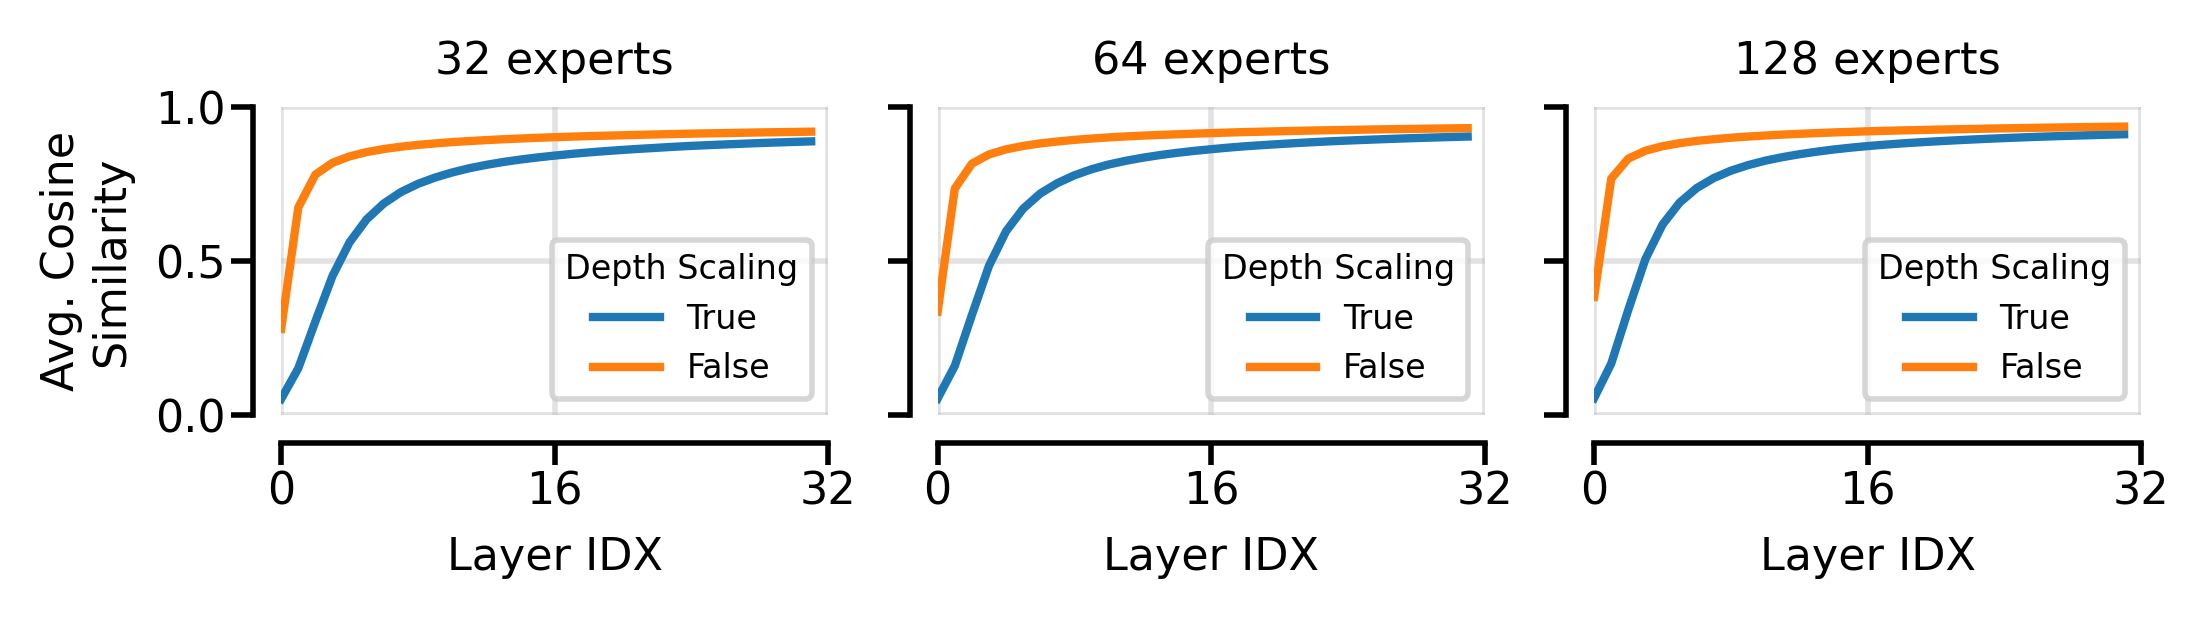

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(6, 1), sharey='row')
format_figure(ax, 8)

dataset_name = 'nvidia_Nemotron-CC-Math-v1_4plus'
dataset_name = 'Salesforce_wikitext_wikitext-2-raw-v1'
attention_kv_head_ratio = 1
for use_depth_scaling in [True, False]:
    for i, num_experts in enumerate([32, 64, 128]):
        results = all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)]
        ax[i].plot(results['all_avg_cos'][:], label=f"{use_depth_scaling}")
        ax[i].set_ylim(0, 1)
        ax[i].set_xlim(0, 32)
        ax[i].set_xticks([0, 16, 32])
        ax[i].set_title(f"{num_experts} experts", fontsize=8)
        ax[i].legend(fontsize=6, title="Depth Scaling", title_fontsize=6)
        ax[i].set_xlabel('Layer IDX', fontsize=8)
ax[0].set_ylabel("Avg. Cosine\nSimilarity", fontsize=8)

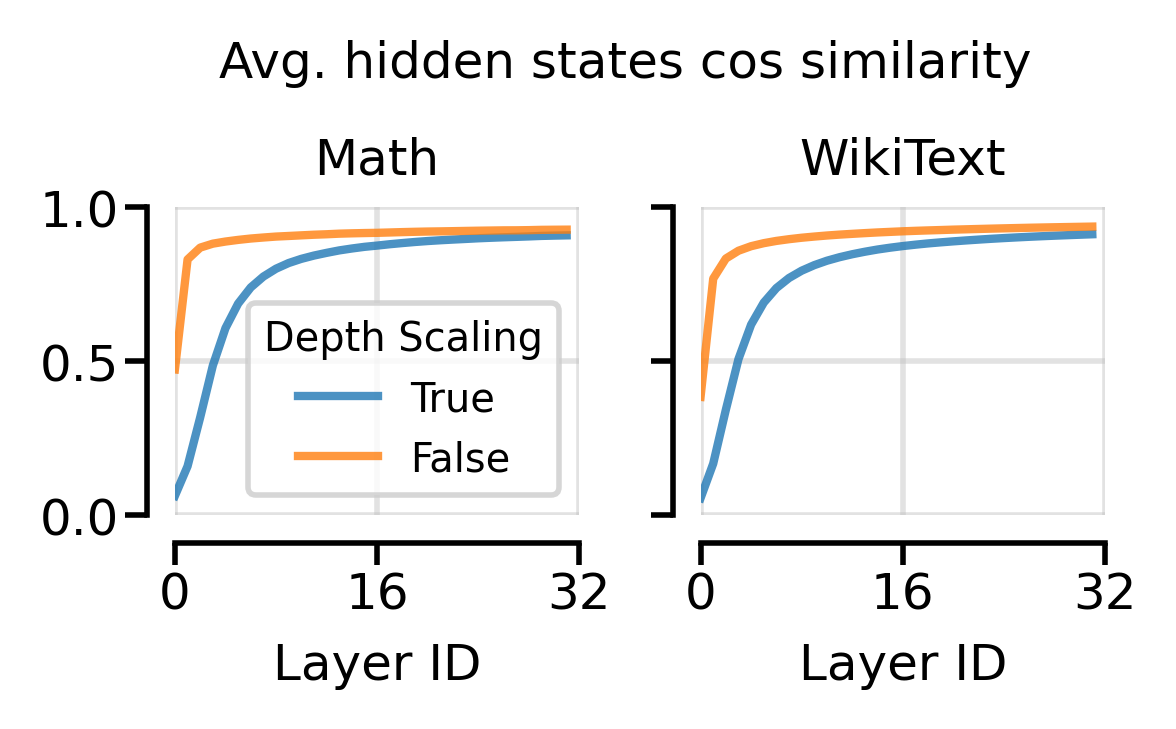

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(3, 1.0), sharey='row')

FONTSIZE = 9

format_figure(ax, FONTSIZE)
# fig.suptitle('Random Initialization Results', fontsize=FONTSIZE)
fig.subplots_adjust(wspace=0.3)

line_config = {
    # 'linestyle': '-',
    'linewidth': 1.5,
    'alpha': 0.8,
}

dataset_name = 'nvidia_Nemotron-CC-Math-v1_4plus'
# dataset_name = 'Salesforce_wikitext_wikitext-2-raw-v1'
attention_kv_head_ratio = 1
for use_depth_scaling in [True, False]:
    for i, num_experts in enumerate([128]):
        results = all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)]
        ax[0].plot(results['all_avg_cos'][:], label=f"{use_depth_scaling}", **line_config)
        ax[0].set_ylim(0, 1)
        ax[0].set_xlim(0, 32)
        ax[0].set_xticks([0, 16, 32])
        # ax[i].set_title(f"{num_experts} experts", fontsize=FONTSIZE)
        ax[0].legend(fontsize=FONTSIZE * 0.8, title="Depth Scaling", title_fontsize=FONTSIZE * 0.8)
        ax[0].set_xlabel('Layer ID', fontsize=FONTSIZE)

# dataset_name = 'nvidia_Nemotron-CC-Math-v1_4plus'
dataset_name = 'Salesforce_wikitext_wikitext-2-raw-v1'
attention_kv_head_ratio = 1
for use_depth_scaling in [True, False]:
    for i, num_experts in enumerate([128]):
        results = all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)]
        ax[1].plot(results['all_avg_cos'][:], label=f"{use_depth_scaling}", **line_config)
        ax[1].set_ylim(0, 1)
        ax[1].set_xlim(0, 32)
        ax[1].set_xticks([0, 16, 32])
        # ax[i].set_title(f"{num_experts} experts", fontsize=FONTSIZE)
        # ax[1].legend(fontsize=FONTSIZE, title="Depth Scaling", title_fontsize=FONTSIZE * 0.9)
        ax[1].set_xlabel('Layer ID', fontsize=FONTSIZE)

# for use_depth_scaling in [True, False]:
#     for i, num_experts in enumerate([128]):
#         results = all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)]
#         ax[1].plot(2 ** results['all_router_stats'][:], label=f"{use_depth_scaling}")
#         ax[1].set_ylim(2, 128)
#         ax[1].set_xlim(0, 32)
#         ax[1].set_xticks([0, 16, 32])
#         ax[1].set_yticks([2, 64, 128])
#         # ax[1].set_title(f"{num_experts} experts", fontsize=FONTSIZE)
#         # ax[1].legend(fontsize=FONTSIZE, title="Depth Scaling", title_fontsize=FONTSIZE * 0.9)
#         ax[1].set_xlabel('Layer ID', fontsize=FONTSIZE)

ax[0].set_title("Math", fontsize=FONTSIZE)
ax[1].set_title("WikiText", fontsize=FONTSIZE)
fig.suptitle("Avg. hidden states cos similarity", fontsize=FONTSIZE, y=1.3)
save_dir = '/home/xwang457/work/nanomoe/figs'
fig.savefig(f"{save_dir}/random_init_hidden_states_cos_similarity.pdf", bbox_inches='tight')

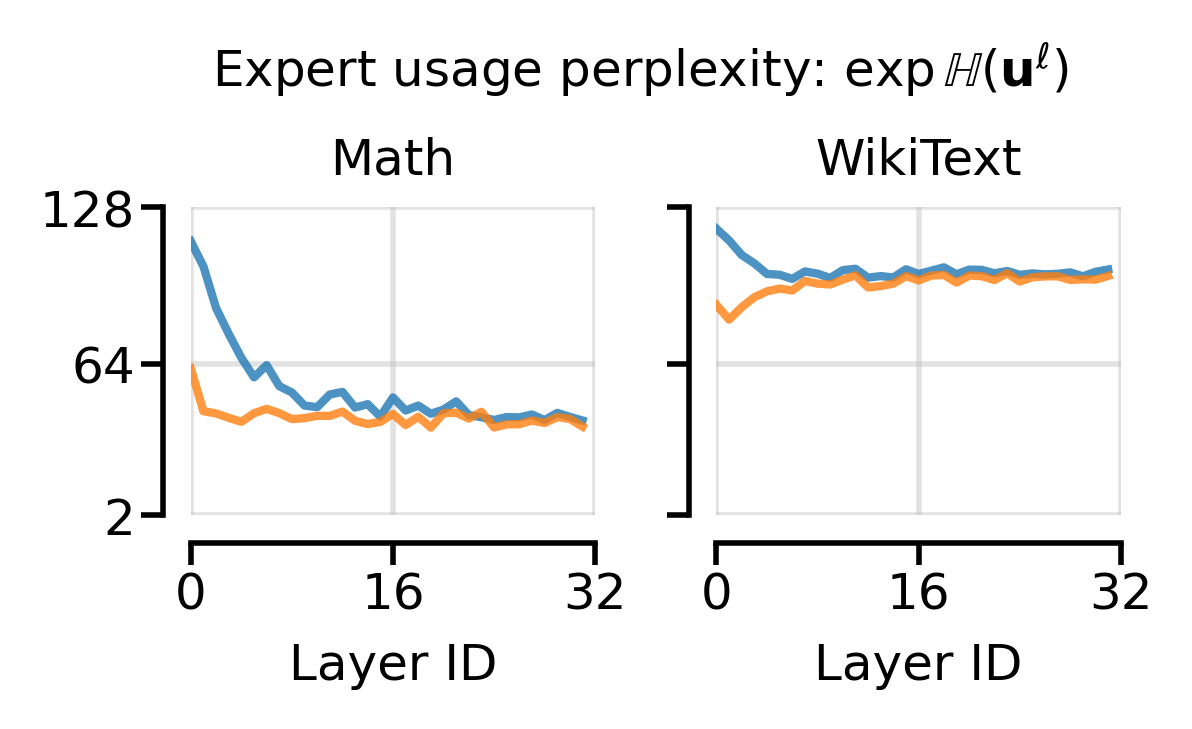

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(3, 1.0), sharey='row')

FONTSIZE = 9
format_figure(ax, FONTSIZE)
# fig.suptitle('Random Initialization Results', fontsize=FONTSIZE)
fig.subplots_adjust(wspace=0.3)

dataset_name = 'nvidia_Nemotron-CC-Math-v1_4plus'
# dataset_name = 'Salesforce_wikitext_wikitext-2-raw-v1'
attention_kv_head_ratio = 1
for use_depth_scaling in [True, False]:
    for i, num_experts in enumerate([128]):
        results = all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)]
        ax[0].plot(2 ** results['all_router_stats'][:], label=f"{use_depth_scaling}", **line_config)
        ax[0].set_ylim(2, 128)
        ax[0].set_xlim(0, 32)
        ax[0].set_xticks([0, 16, 32])
        ax[0].set_ylim(2, 128)
        ax[0].set_yticks([2, 64, 128])
        # ax[i].set_title(f"{num_experts} experts", fontsize=FONTSIZE)
        # ax[0].legend(fontsize=FONTSIZE * 0.8, title="Depth Scaling", title_fontsize=FONTSIZE * 0.8)
        ax[0].set_xlabel('Layer ID', fontsize=FONTSIZE)

# dataset_name = 'nvidia_Nemotron-CC-Math-v1_4plus'
dataset_name = 'Salesforce_wikitext_wikitext-2-raw-v1'
attention_kv_head_ratio = 1
for use_depth_scaling in [True, False]:
    for i, num_experts in enumerate([128]):
        results = all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)]
        ax[1].plot(2 ** results['all_router_stats'][:], label=f"{use_depth_scaling}", **line_config)
        ax[1].set_ylim(2, 128)
        ax[1].set_xlim(0, 32)
        ax[1].set_xticks([0, 16, 32])
        # ax[i].set_title(f"{num_experts} experts", fontsize=FONTSIZE)
        # ax[1].legend(fontsize=FONTSIZE, title="Depth Scaling", title_fontsize=FONTSIZE * 0.9)
        ax[1].set_xlabel('Layer ID', fontsize=FONTSIZE)

# for use_depth_scaling in [True, False]:
#     for i, num_experts in enumerate([128]):
#         results = all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)]
#         ax[1].plot(2 ** results['all_router_stats'][:], label=f"{use_depth_scaling}", **line_config)
#         ax[1].set_ylim(2, 128)
#         ax[1].set_xlim(0, 32)
#         ax[1].set_xticks([0, 16, 32])
#         ax[1].set_yticks([2, 64, 128])
#         # ax[1].set_title(f"{num_experts} experts", fontsize=FONTSIZE)
#         # ax[1].legend(fontsize=FONTSIZE, title="Depth Scaling", title_fontsize=FONTSIZE * 0.9)
#         ax[1].set_xlabel('Layer ID', fontsize=FONTSIZE)

ax[0].set_title("Math", fontsize=FONTSIZE)
ax[1].set_title("WikiText", fontsize=FONTSIZE)
# fig.suptitle("Avg. hidden states cos similarity", fontsize=FONTSIZE, y=1.3)
fig.suptitle("Expert usage perplexity: " + r"$\exp{\mathbb{H}}(\mathbf{u}^\ell)$", fontsize=FONTSIZE, y=1.3)
save_dir = '/home/xwang457/work/nanomoe/figs'
fig.savefig(f"{save_dir}/random_init_expert_usage_perplexity.pdf", bbox_inches='tight')

Text(0, 0.5, 'Expert usage\nperplexity')

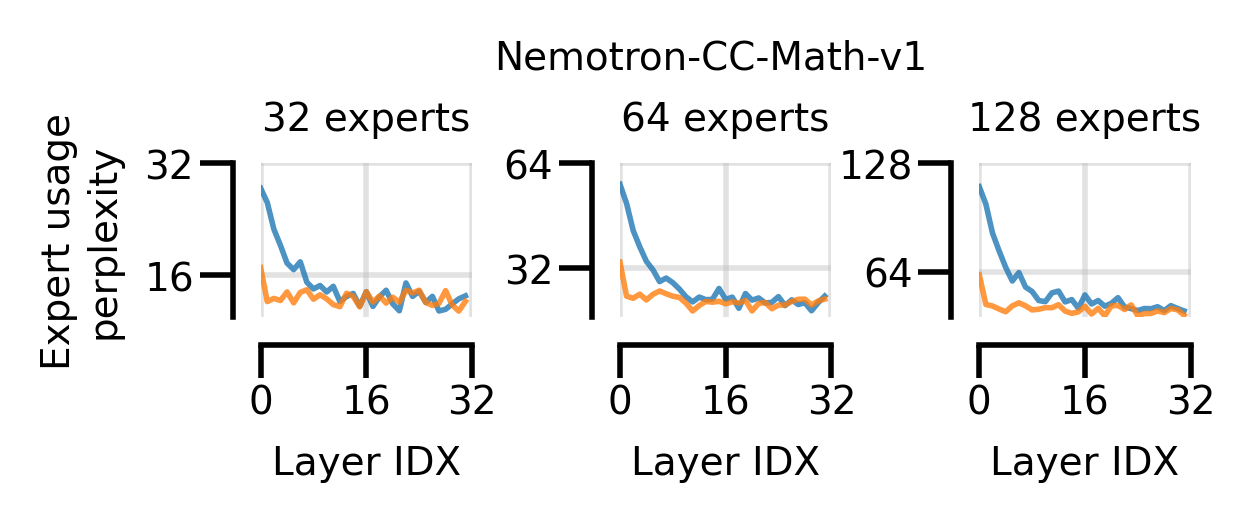

In [178]:
fig, ax = plt.subplots(1, 3, figsize=(3, 0.5))
fig.subplots_adjust(wspace=0.7)
FONTSIZE = 7
format_figure(ax, FONTSIZE)

dataset_name = 'nvidia_Nemotron-CC-Math-v1_4plus'
# dataset_name = 'Salesforce_wikitext_wikitext-2-raw-v1'
attention_kv_head_ratio = 1
for use_depth_scaling in [True, False]:
    for i, num_experts in enumerate([32, 64, 128]):
        results = all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)]
        ax[i].plot(2 ** results['all_router_stats'][:], label=f"{use_depth_scaling}", linewidth=1.0, alpha=0.8)
        ax[i].set_ylim(top=num_experts)
        ax[i].set_xlim(0, 32)
        ax[i].set_xticks([0, 16, 32])
        ax[i].set_title(f"{num_experts} experts", fontsize=FONTSIZE)
        ax[i].set_xlabel('Layer IDX', fontsize=FONTSIZE)
        ax[i].set_yticks([num_experts  // 2, num_experts])
        # ax[i].legend(fontsize=FONTSIZE, title="Depth Scaling", title_fontsize=FONTSIZE)
fig.suptitle(dataset_name.split('_')[1], fontsize=FONTSIZE, y=1.5)
ax[0].set_ylabel("Expert usage\nperplexity", fontsize=FONTSIZE)

Text(0, 0.5, 'Expert usage\nperplexity')

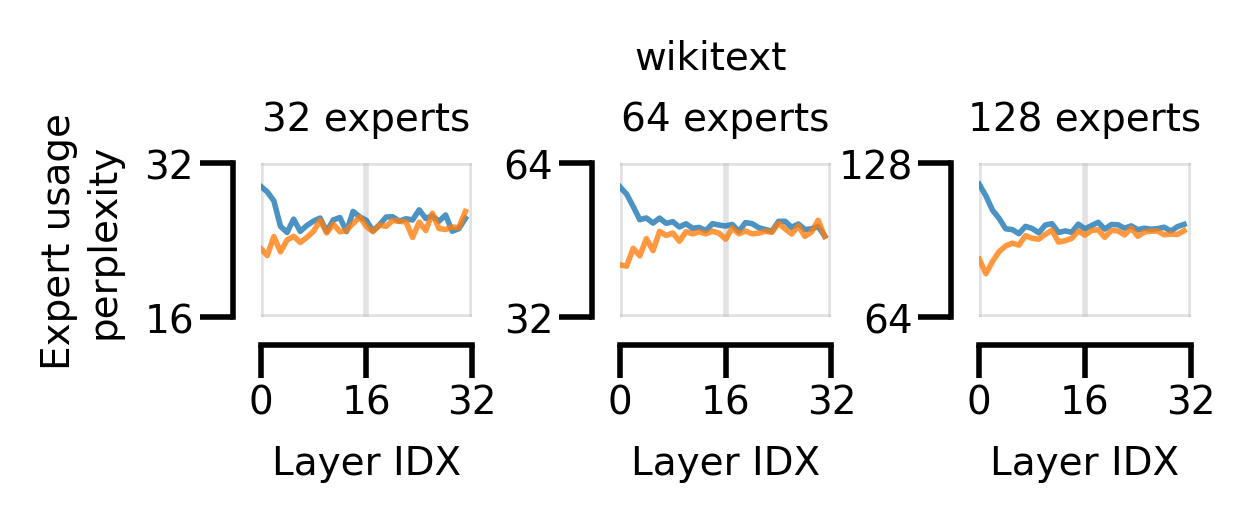

In [179]:
fig, ax = plt.subplots(1, 3, figsize=(3, 0.5))
fig.subplots_adjust(wspace=0.7)
FONTSIZE = 7
format_figure(ax, FONTSIZE)

# dataset_name = 'nvidia_Nemotron-CC-Math-v1_4plus'
dataset_name = 'Salesforce_wikitext_wikitext-2-raw-v1'
attention_kv_head_ratio = 1
for use_depth_scaling in [True, False]:
    for i, num_experts in enumerate([32, 64, 128]):
        results = all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)]
        ax[i].plot(2 ** results['all_router_stats'][:], label=f"{use_depth_scaling}", linewidth=1.0, alpha=0.8)
        ax[i].set_ylim(top=num_experts)
        ax[i].set_xlim(0, 32)
        ax[i].set_xticks([0, 16, 32])
        ax[i].set_title(f"{num_experts} experts", fontsize=FONTSIZE)
        ax[i].set_xlabel('Layer IDX', fontsize=FONTSIZE)
        ax[i].set_yticks([num_experts  // 2, num_experts])
        # ax[i].legend(fontsize=FONTSIZE, title="Depth Scaling", title_fontsize=FONTSIZE)
fig.suptitle(dataset_name.split('_')[1], fontsize=FONTSIZE, y=1.5)
ax[0].set_ylabel("Expert usage\nperplexity", fontsize=FONTSIZE)

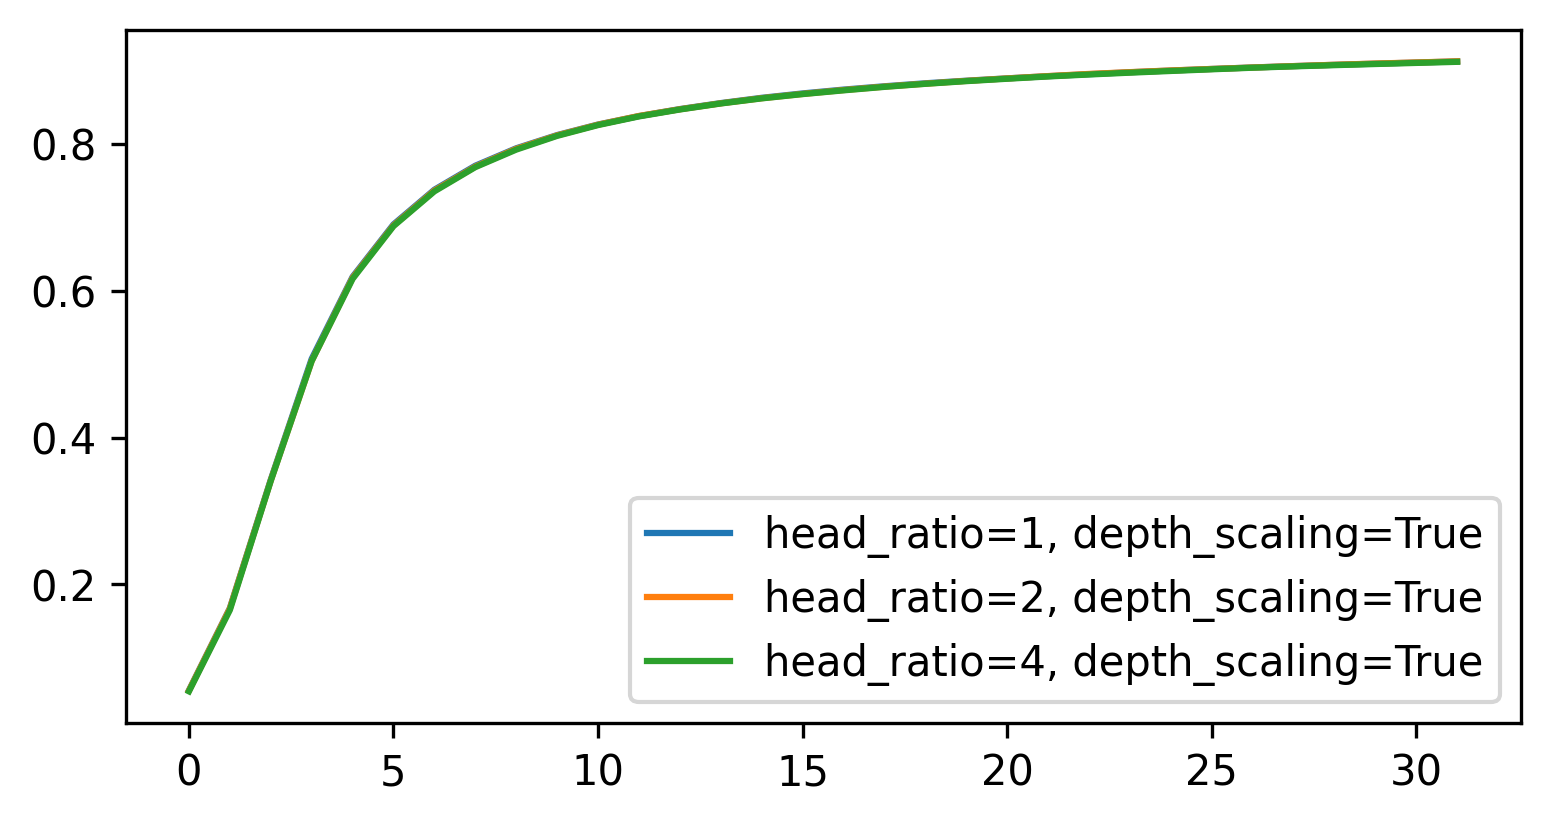

In [86]:
dataset_name = 'Salesforce_wikitext_wikitext-2-raw-v1'
plt.figure(figsize=(6, 3))
num_experts = 128
for use_depth_scaling in [True]:
    for attention_kv_head_ratio in [1, 2, 4]:
        results = all_results[(dataset_name, use_depth_scaling, num_experts, attention_kv_head_ratio)]
        plt.plot(results['all_avg_cos'][:], label=f"head_ratio={attention_kv_head_ratio}, depth_scaling={use_depth_scaling}")
plt.legend()